# Analisa Data Menggunakan Random Forest

## Workflow

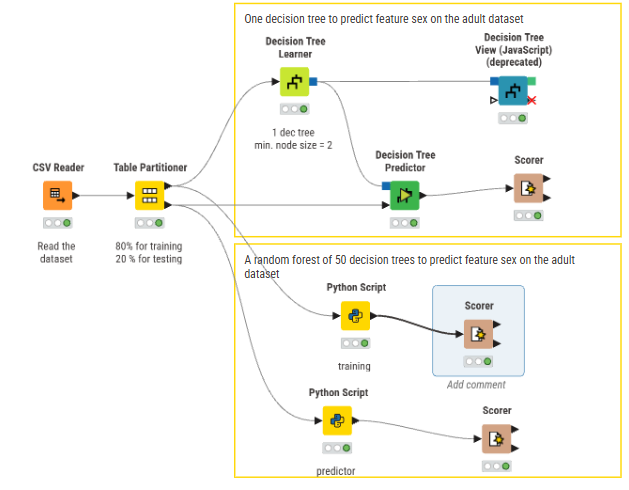


## 1. Deskripsi Dataset

Dataset yang digunakan adalah **Car Evaluation Dataset**. Dataset ini berisi data penilaian mobil berdasarkan beberapa atribut kategorikal. Kolom target yang diprediksi adalah `class`.

Fitur yang digunakan:

| No | Kolom | Keterangan |
|---:|---|---|
| 1 | `buying` | Harga beli mobil |
| 2 | `maint` | Biaya perawatan |
| 3 | `doors` | Jumlah pintu |
| 4 | `persons` | Kapasitas penumpang |
| 5 | `lug_boot` | Ukuran bagasi |
| 6 | `safety` | Tingkat keamanan |
| 7 | `class` | Target/kelas evaluasi mobil |

Kelas target terdiri dari:

- `unacc`
- `acc`
- `good`
- `vgood`

## 2. Workflow KNIME

Workflow dimulai dari node **CSV Reader** untuk membaca file `car_evaluation.csv`. Setelah data terbaca, data dibagi menjadi data training dan testing menggunakan node **Table Partitioning** dengan komposisi:

- **80% data training**
- **20% data testing**

Pada workflow juga masih terdapat bagian **Decision Tree** sebagai pembanding. Namun fokus utama tugas ini adalah Random Forest menggunakan script.

Bagian Random Forest menggunakan dua Python Script Node:

| Node | Fungsi |
|---|---|
| Python Script Training RF | Melatih model Random Forest dari data training dan menyimpan model ke file `.joblib` |
| Python Script Predictor RF | Membaca model `.joblib`, melakukan prediksi pada data testing, lalu menghasilkan kolom `Prediction (class)` |
| Scorer | Membandingkan kolom asli `class` dengan kolom prediksi `Prediction (class)` |

Node Random Forest bawaan KNIME seperti **Random Forest Learner**, **Random Forest Predictor**, **Tree Ensemble Model Extract**, dan **Table to PMML Ensemble** tidak digunakan lagi karena model sudah dibuat dan disimpan menggunakan Python Script.

## 3. Script Training Random Forest

Script berikut dimasukkan ke node **Python Script Training RF**. Input node ini berasal dari output training pada **Table Partitioning**.

Fungsi utama script training:

1. Mengambil data training dari KNIME.
2. Memisahkan fitur `X_train` dan target `y_train`.
3. Melakukan encoding pada data kategorikal menggunakan `OneHotEncoder`.
4. Membuat model `RandomForestClassifier` dari `sklearn`.
5. Melatih model menggunakan `model.fit(X_train, y_train)`.
6. Menyimpan model ke file `.joblib`.
7. Menghasilkan kolom prediksi untuk data training agar bisa dievaluasi dengan Scorer.

In [ ]:
import knime.scripting.io as knio
import pandas as pd
import os
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


# 1. Ambil data training dari KNIME
train_df = knio.input_tables[0].to_pandas()

# 2. Tentukan kolom target
target_col = "class"

if target_col not in train_df.columns:
    raise ValueError(f"Kolom target '{target_col}' tidak ditemukan. Kolom tersedia: {list(train_df.columns)}")

# 3. Pisahkan fitur X dan target y
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

# 4. Tentukan kolom kategori
categorical_cols = X_train.columns.tolist()

# 5. Preprocessing data kategori
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# 6. Buat model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=123
)

# 7. Gabungkan preprocessing dan model
model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("classifier", rf_model)
    ]
)

# 8. Training model Random Forest
model.fit(X_train, y_train)

# 9. Simpan model ke file .joblib
model_dir = "model"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "rf_car_evaluation_model.joblib")
joblib.dump(model, model_path)

# 10. Prediksi data training
train_df["Prediction (class)"] = model.predict(X_train)

# 11. Output ke KNIME
knio.output_tables[0] = knio.Table.from_pandas(train_df)

### Penjelasan Script Training

Pada bagian awal, script mengambil data dari KNIME menggunakan `knio.input_tables[0].to_pandas()`. Setelah itu kolom `class` ditentukan sebagai target. Fitur yang digunakan untuk pelatihan adalah semua kolom selain `class`.

Karena seluruh fitur pada dataset `car_evaluation.csv` berupa kategori, maka data perlu diubah terlebih dahulu menjadi bentuk numerik. Proses ini dilakukan menggunakan `OneHotEncoder`. Setelah preprocessing selesai, model Random Forest dibuat menggunakan:

```python
RandomForestClassifier(n_estimators=100, random_state=123)
```

Parameter `n_estimators=100` berarti model menggunakan 100 pohon keputusan. Setelah model dilatih, model disimpan menggunakan `joblib.dump()` agar bisa dipakai kembali oleh script predictor.

## 4. Script Predictor / Testing Random Forest

Script berikut dimasukkan ke node **Python Script Predictor RF**. Input node ini berasal dari output testing pada **Table Partitioning**.

Fungsi utama script predictor:

1. Mengambil data testing dari KNIME.
2. Memisahkan fitur testing dari kolom target.
3. Memuat model `.joblib` yang sudah dibuat oleh script training.
4. Melakukan prediksi terhadap data testing.
5. Menambahkan kolom `Prediction (class)`.
6. Mengirimkan hasil ke Scorer.

In [ ]:
import knime.scripting.io as knio
import pandas as pd
import os
import joblib


# 1. Ambil data testing dari KNIME
test_df = knio.input_tables[0].to_pandas()

# 2. Tentukan kolom target
target_col = "class"

if target_col not in test_df.columns:
    raise ValueError(f"Kolom target '{target_col}' tidak ditemukan. Kolom tersedia: {list(test_df.columns)}")

# 3. Pisahkan fitur X_test
X_test = test_df.drop(columns=[target_col])

# 4. Load model Random Forest
model_path = os.path.join("model", "rf_car_evaluation_model.joblib")

if not os.path.exists(model_path):
    raise FileNotFoundError(
        "Model belum ditemukan. Jalankan dulu Python Script Training RF sebelum menjalankan predictor."
    )

model = joblib.load(model_path)

# 5. Prediksi data testing
prediction = model.predict(X_test)

# 6. Tambahkan kolom prediksi
test_df["Prediction (class)"] = prediction

# 7. Output hasil prediksi ke KNIME
knio.output_tables[0] = knio.Table.from_pandas(test_df)

### Penjelasan Script Predictor

Pada script predictor, data testing diambil dari KNIME. Script kemudian membuka model yang sudah disimpan pada tahap training menggunakan `joblib.load()`. Setelah model berhasil dimuat, model melakukan prediksi pada data testing dengan perintah:

```python
prediction = model.predict(X_test)
```

Hasil prediksi dimasukkan ke dalam kolom baru bernama `Prediction (class)`. Kolom inilah yang kemudian dibandingkan dengan kolom asli `class` pada node Scorer.

## 5. Konfigurasi Scorer

Pada node **Scorer**, kolom yang dibandingkan harus diatur sebagai berikut:

| Pengaturan | Kolom |
|---|---|
| First column | `class` |
| Second column | `Prediction (class)` |

Artinya, `class` adalah label asli dari dataset, sedangkan `Prediction (class)` adalah hasil prediksi model Random Forest.

## 6. Hasil Evaluasi Data Training

Hasil evaluasi pada data training menunjukkan bahwa seluruh data training diprediksi dengan benar.

Confusion matrix data training:

| Actual \ Predicted | unacc | acc | vgood | good |
|---|---:|---:|---:|---:|
| unacc | 968 | 0 | 0 | 0 |
| acc | 0 | 307 | 0 | 0 |
| vgood | 0 | 0 | 52 | 0 |
| good | 0 | 0 | 0 | 55 |

Total data training:

```text
968 + 307 + 52 + 55 = 1382 data
```

Jumlah prediksi benar:

```text
1382 data
```

Akurasi training:

```text
1382 / 1382 = 100%
```

Hasil ini menunjukkan bahwa model sangat cocok terhadap data training.

## 7. Hasil Evaluasi Data Testing

Evaluasi utama dilakukan pada data testing karena data ini tidak digunakan saat proses pelatihan model. Hasil confusion matrix testing adalah sebagai berikut:

| Actual \ Predicted | unacc | acc | vgood | good |
|---|---:|---:|---:|---:|
| unacc | 240 | 2 | 0 | 0 |
| acc | 2 | 74 | 0 | 1 |
| vgood | 0 | 2 | 11 | 0 |
| good | 0 | 5 | 2 | 7 |

Total data testing:

```text
346 data
```

Jumlah prediksi benar dihitung dari nilai diagonal:

```text
240 + 74 + 11 + 7 = 332 data
```

Akurasi testing:

```text
332 / 346 = 95,95%
```

Hasil ini menunjukkan bahwa model Random Forest mampu mengklasifikasikan data testing dengan baik. Kesalahan prediksi masih muncul pada beberapa kelas, terutama kelas `good` yang beberapa datanya diprediksi sebagai `acc` atau `vgood`. Namun secara umum performa model tetap tinggi karena sebagian besar data berhasil diklasifikasikan dengan benar.

## 8. Perbandingan Hasil Training dan Testing

| Data | Jumlah Data | Prediksi Benar | Akurasi |
|---|---:|---:|---:|
| Training | 1382 | 1382 | 100% |
| Testing | 346 | 332 | 95,95% |

Dari hasil tersebut, akurasi training lebih tinggi dibandingkan akurasi testing. Hal ini wajar karena data training adalah data yang digunakan untuk membentuk model. Akurasi testing lebih penting untuk dilaporkan karena menggambarkan kemampuan model terhadap data baru.

Model Random Forest memperoleh akurasi testing sekitar **95,95%**, sehingga dapat dikatakan bahwa model berhasil melakukan klasifikasi dengan performa yang baik.

## 9. Kesimpulan

Berdasarkan workflow dan hasil evaluasi, proyek ini sudah sesuai dengan arahan tugas. Random Forest tidak dibuat menggunakan node bawaan KNIME, melainkan menggunakan **Python Script Node** dengan library `scikit-learn`.

Tahap training dilakukan menggunakan data training dari hasil partitioning. Model dilatih menggunakan `RandomForestClassifier`, kemudian disimpan dalam format `.joblib`. Tahap predictor dilakukan dengan cara memuat model `.joblib`, melakukan prediksi pada data testing, dan menghasilkan kolom `Prediction (class)`.

Hasil evaluasi menunjukkan:

- Akurasi training sebesar **100%**.
- Akurasi testing sebesar **95,95%**.

Dengan demikian, model Random Forest yang dibuat menggunakan Python Script mampu melakukan klasifikasi data `car_evaluation.csv` dengan baik.